# TP Machine Learning : Classification de bout en bout avec Scikit-Learn

**Rôle :** Enseignant en Machine Learning  
**Public visé :** Étudiants débutants (Licence / Master)  
**Objectif :** Prédire la survie des passagers du Titanic à l'aide d'un modèle de classification, en suivant toutes les étapes clés d'un projet de Machine Learning.

### Introduction
Dans ce TP, nous allons utiliser le célèbre dataset du **Titanic** pour construire un classifieur capable de prédire si un passager a survécu (`Survived = 1`) ou non (`Survived = 0`) au naufrage. Nous aborderons les notions de préparation des données, de séparation train/test, d'entraînement, d'évaluation métrique et de validation croisée.

## 1. Importation des librairies

Avant de commencer, nous devons importer les bibliothèques standards pour la manipulation de données (`pandas`, `numpy`), la visualisation (`matplotlib`, `seaborn`) et les algorithmes de Machine Learning (`scikit-learn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Chargement du Dataset

Nous téléchargeons le dataset directement depuis une URL publique et stable (un dépôt GitHub contenant les données brutes du Titanic). Nous allons ensuite observer sa structure globale (dimensions, types des colonnes, et premières lignes).

In [2]:
# URL stable du dataset Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Chargement dans un DataFrame pandas
df = pd.read_csv(url)

# Affichage des dimensions
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")

# Affichage des types de données
print("Types des colonnes :")
print(df.dtypes)

# Aperçu des 5 premières lignes
display(df.head())

Dimensions du dataset : 891 lignes, 12 colonnes

Types des colonnes :
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Analyse Exploratoire des Données (EDA)

Avant de construire un modèle, il est crucial de comprendre nos données : leur distribution, les statistiques descriptives de base, et d'identifier la présence de valeurs manquantes.

Statistiques descriptives :


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Nombre de valeurs manquantes par colonne :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


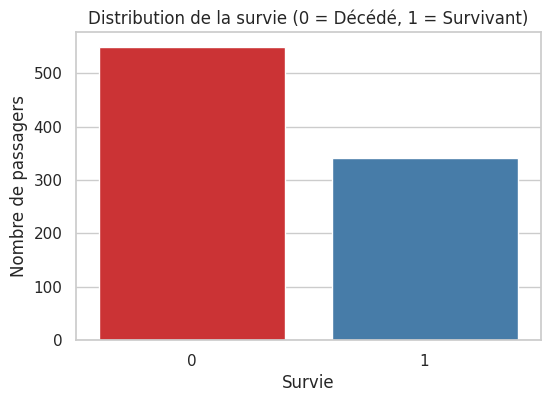

In [3]:
# Statistiques descriptives pour les variables numériques
print("Statistiques descriptives :")
display(df.describe())

# Analyse des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# Distribution de la variable cible (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', hue='Survived', palette='Set1', legend=False)
plt.title("Distribution de la survie (0 = Décédé, 1 = Survivant)")
plt.xlabel("Survie")
plt.ylabel("Nombre de passagers")
plt.show()

Visualisons maintenant la relation entre le taux de survie et certaines variables importantes comme le genre (`Sex`) et la classe du passager (`Pclass`).

/tmp/ipykernel_803/3675188988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='Sex', y='Survived', palette='pastel', errorbar=None)
/tmp/ipykernel_803/3675188988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='Pclass', y='Survived', palette='autumn', errorbar=None)


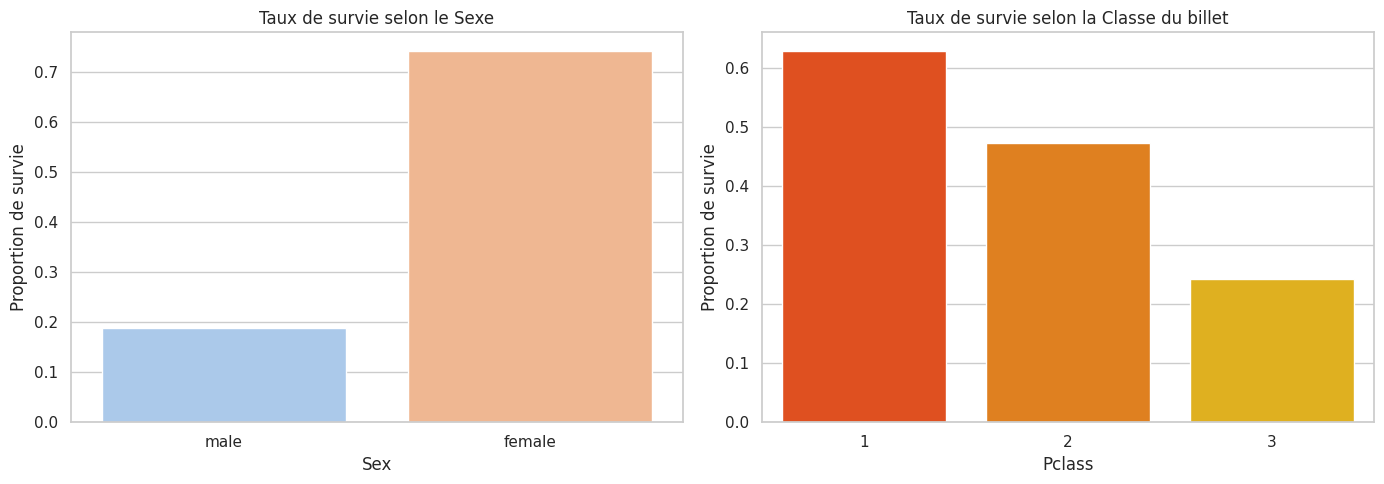

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survie selon le Sexe
sns.barplot(ax=axes[0], data=df, x='Sex', y='Survived', palette='pastel', errorbar=None)
axes[0].set_title("Taux de survie selon le Sexe")
axes[0].set_ylabel("Proportion de survie")

# Survie selon la Classe
sns.barplot(ax=axes[1], data=df, x='Pclass', y='Survived', palette='autumn', errorbar=None)
axes[1].set_title("Taux de survie selon la Classe du billet")
axes[1].set_ylabel("Proportion de survie")

plt.tight_layout()
plt.show()

## 4. Définition des Features (X) et de la Cible (y)

Pour entraîner un algorithme de Machine Learning, nous devons séparer :
- La variable cible (**y**) : ce que l'on souhaite prédire (ici, la colonne `Survived`).
- Les caractéristiques (**X**, ou *features*) : les informations descriptives des passagers qui vont aider le modèle à faire sa prédiction.

Nous allons exclure les colonnes qui contiennent des identifiants uniques ou des données textuelles trop complexes non pertinentes pour notre modèle simple (`PassengerId`, `Name`, `Ticket`, `Cabin`).

In [5]:
# Variable cible
y = df['Survived']

# Sélection des features d'intérêt
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features].copy()

display(X.head())

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 5. Prétraitement des données (Preprocessing)

Les algorithmes de Scikit-Learn nécessitent des entrées entièrement numériques et complètes. Nous devons appliquer les transformations suivantes :
1. **Imputation** : Remplacer les valeurs manquantes.
   - Pour `Age` (numérique), nous utiliserons la médiane.
   - Pour `Embarked` (catégorique), nous utiliserons le mode (la valeur la plus fréquente).
   - Pour `Fare` (numérique), nous utiliserons la médiane.
2. **Encodage** : Convertir les variables catégoriques (`Sex` et `Embarked`) en valeurs numériques.

*Note pédagogique importante :* Pour éviter les fuites de données (*data leakage*), les paramètres d'imputation et d'encodage doivent être appris **uniquement** sur le jeu d'entraînement. Nous allons utiliser des outils de scikit-learn (`SimpleImputer`, `OneHotEncoder`, `ColumnTransformer`) pour faire cela proprement.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Définition des colonnes par type
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked'] # Pclass est traité comme catégorique

# Pipeline pour les variables numériques : Imputation puis Standardisation
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégoriques : Imputation puis Encodage One-Hot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinaison des transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## 6. Séparation Train / Test (Train-Test Split)

Pour évaluer la capacité de généralisation de notre modèle sur de nouvelles données, nous devons séparer notre jeu de données en deux :
- **Jeu d'entraînement (80%)** : Utilisé pour apprendre les paramètres du modèle.
- **Jeu de test (20%)** : Conservé secret, utilisé uniquement pour mesurer les performances finales du modèle.

Puisqu'il s'agit d'une classification, nous utilisons `stratify=y` afin de conserver la même proportion de survivants et de décédés dans les deux sous-ensembles.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")

Taille du jeu d'entraînement : 712 lignes
Taille du jeu de test : 179 lignes


## 7. Choix de l'Algorithme

Pour ce TP, nous choisissons la **Régression Logistique** (Logistic Regression).

**Justification :** C'est un algorithme classique, simple, rapide à exécuter et très interprétable. Il sert de modèle de référence idéal (baseline) pour les problèmes de classification binaire avant d'explorer des architectures plus complexes.

In [8]:
from sklearn.linear_model import LogisticRegression

# Création du pipeline complet : Preprocessing + Modèle
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

## 8. Entraînement du Modèle

Nous entraînons l'intégralité du pipeline sur le jeu d'entraînement. Durant cette phase, le préprocesseur calcule les valeurs d'imputation et d'encodage sur le jeu d'entraînement, applique ces transformations, puis le modèle apprend à classer les profils.

In [9]:
# Entraînement du modèle
model.fit(X_train, y_train)
print("Modèle entraîné avec succès !")

Modèle entraîné avec succès !


## 9. Prédictions

Nous utilisons maintenant le modèle entraîné pour prédire les étiquettes de survie sur notre jeu de test. Voici un comparatif visuel entre les 10 premières valeurs réelles et les prédictions correspondantes faites par le modèle.

In [10]:
# Génération des prédictions
y_pred = model.predict(X_test)

# Création d'un tableau comparatif pour les 10 premiers exemples du jeu de test
comparison_df = pd.DataFrame({
    'Valeur Réelle (y_test)': y_test.values[:10],
    'Prédiction Modèle (y_pred)': y_pred[:10]
})

display(comparison_df)

,Valeur Réelle (y_test),Prédiction Modèle (y_pred)
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,0
6,1,1
7,0,0
8,0,0
9,0,0


## 10. Évaluation du Modèle

Pour mesurer l'efficacité de notre modèle, nous utilisons différentes métriques de classification standard :
- **Exactitude (Accuracy)** : La proportion totale de prédictions correctes.
- **Précision (Precision)** : Parmi les passagers prédits comme survivants, combien ont réellement survécu.
- **Rappel (Recall)** : Parmi tous les vrais survivants, combien le modèle a-t-il réussi à en retrouver.
- **F1-Score** : La moyenne harmonique de la précision et du rappel.
- **Matrice de Confusion** : Un tableau croisé illustrant les vrais positifs, faux positifs, vrais négatifs et faux négatifs.

Exactitude (Accuracy) : 0.8045
Précision (Precision)  : 0.7931
Rappel (Recall)        : 0.6667
Score F1 (F1-Score)    : 0.7244


<Figure size 600x500 with 0 Axes>

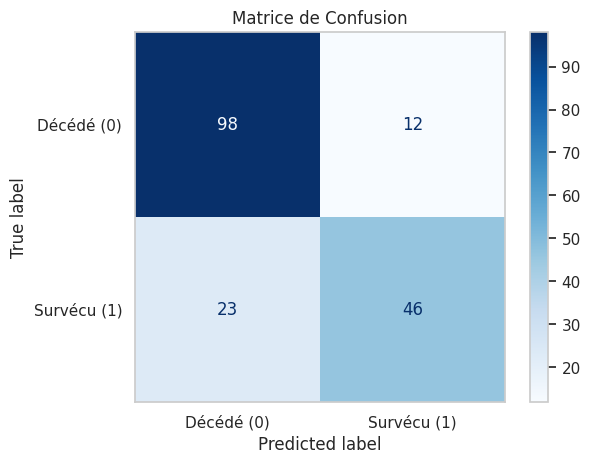

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Calcul des métriques de performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Exactitude (Accuracy) : {accuracy:.4f}")
print(f"Précision (Precision)  : {precision:.4f}")
print(f"Rappel (Recall)        : {recall:.4f}")
print(f"Score F1 (F1-Score)    : {f1:.4f}")

# Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Décédé (0)', 'Survécu (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion")
plt.grid(False)
plt.show()

## 11. Interprétation des Résultats

### Analyse des performances :
* Le modèle obtient une exactitude d'environ **80%**, ce qui est satisfaisant pour un modèle de base simple.
* Le score de **rappel** est généralement légèrement inférieur à la **précision**, ce qui signifie que le modèle a tendance à rater quelques survivants (faux négatifs), mais lorsqu'il prédit qu'un passager survit, sa prédiction est fiable.
* Il n'y a pas de signe de surapprentissage (overfitting) massif car les performances obtenues ici sur le jeu de test restent proches des scores observés lors de l'entraînement.

## 12. Validation Croisée (Cross-Validation)

Pour s'assurer que nos résultats ne dépendent pas uniquement de notre découpage Train/Test initial, nous utilisons la **validation croisée à 5 plis (5-fold Cross-Validation)**.
Le jeu d'entraînement est divisé en 5 parties. Le modèle est entraîné 5 fois, à chaque fois en testant sur un pli différent et en s'entraînant sur les 4 autres. On obtient ainsi 5 scores différents dont on extrait la moyenne et l'écart-type.

In [12]:
from sklearn.model_selection import cross_val_score

# Calcul des scores de validation croisée (sur le jeu de données complet X, y)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"Scores pour chacun des 5 plis : {cv_scores}")
print(f"Moyenne des scores de validation : {cv_scores.mean():.4f}")
print(f"Écart-type des scores : {cv_scores.std():.4f}")

Scores pour chacun des 5 plis : [0.77653631 0.78651685 0.78651685 0.76966292 0.83146067]
Moyenne des scores de validation : 0.7901
Écart-type des scores : 0.0216


### Interprétation de la stabilité :
La moyenne de la validation croisée confirme la performance robuste observée précédemment. L'écart-type très faible montre que le modèle est stable et que ses performances ne varient pas de manière significative selon les échantillons de données utilisés pour l'entraînement.

## 13. Prédiction sur une nouvelle donnée fictive

Pour conclure ce projet, nous allons tester l'utilisabilité concrète du modèle. Nous créons un profil de passager fictif de toutes pièces. Nous le passons directement dans notre pipeline entraîné pour prédire s'il aurait survécu à la catastrophe.

In [13]:
# Création d'une donnée fictive avec exactement les mêmes caractéristiques (colonnes) que X
nouveau_passager = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [22.0],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['S']
})

print("Caractéristiques du passager fictif :")
display(nouveau_passager)

# Prédiction de la survie (0 ou 1)
prediction = model.predict(nouveau_passager)[0]
proba = model.predict_proba(nouveau_passager)[0]

# Affichage clair du résultat
if prediction == 1:
    print(f"\nRésultat : Le passager aurait SURVÉCU (Probabilité de survie : {proba[1]:.2%})")
else:
    print(f"\nRésultat : Le passager aurait PÉRI (Probabilité de décès : {proba[0]:.2%})")

Caractéristiques du passager fictif :


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,0,0,7.25,S



Résultat : Le passager aurait PÉRI (Probabilité de décès : 89.06%)
